In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("dataset/messy_dataset.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Column names:")
print(df.columns.tolist())

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [4]:
# Data Quality Report

print("===== DATA QUALITY REPORT =====\n")

# Dataset shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Missing values
print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

# Duplicate rows
print("\n===== DUPLICATE ROWS =====")
print("Number of duplicate rows:", df.duplicated().sum())

# Data types
print("\n===== DATA TYPES =====")
print(df.dtypes)

# Basic statistics
print("\n===== BASIC STATISTICS =====")
display(df.describe(include="all"))

===== DATA QUALITY REPORT =====

Number of rows: 891
Number of columns: 12

===== MISSING VALUES =====
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

===== DUPLICATE ROWS =====
Number of duplicate rows: 0

===== DATA TYPES =====
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

===== BASIC STATISTICS =====


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [5]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
# Calculate missing-value percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage.round(2)
})

missing_report

,Missing Values,Missing Percentage
PassengerId,0,0.00
Survived,0,0.00
Pclass,0,0.00
Name,0,0.00
Sex,0,0.00
Age,177,19.87
SibSp,0,0.00
Parch,0,0.00
Ticket,0,0.00
Fare,0,0.00


In [7]:
# Check duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [8]:
# Check current data types

print("Current data types:")
print(df.dtypes)

Current data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [9]:
# Check numerical columns for unusual values

print("Minimum values:")
print(df.select_dtypes(include=np.number).min())

print("\nMaximum values:")
print(df.select_dtypes(include=np.number).max())

Minimum values:
PassengerId    1.00
Survived       0.00
Pclass         1.00
Age            0.42
SibSp          0.00
Parch          0.00
Fare           0.00
dtype: float64

Maximum values:
PassengerId    891.0000
Survived         1.0000
Pclass           3.0000
Age             80.0000
SibSp            8.0000
Parch            6.0000
Fare           512.3292
dtype: float64


In [10]:
# Create a copy of the original dataset

df_clean = df.copy()

print("Backup created successfully!")
print("Original rows:", len(df))
print("Rows to clean:", len(df_clean))

Backup created successfully!
Original rows: 891
Rows to clean: 891


In [11]:
# Check missing values before cleaning

print("Missing values before cleaning:")
print(df_clean.isnull().sum())

Missing values before cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [12]:
# Fill missing Age values with the median age

age_median = df_clean["Age"].median()

df_clean["Age"] = df_clean["Age"].fillna(age_median)

print("Missing Age values after cleaning:",
      df_clean["Age"].isnull().sum())

Missing Age values after cleaning: 0


In [13]:
# Fill missing Embarked values with the most common value

embarked_mode = df_clean["Embarked"].mode()[0]

df_clean["Embarked"] = df_clean["Embarked"].fillna(embarked_mode)

print("Missing Embarked values after cleaning:",
      df_clean["Embarked"].isnull().sum())

Missing Embarked values after cleaning: 0


In [14]:
# Fill missing Cabin values

df_clean["Cabin"] = df_clean["Cabin"].fillna("Unknown")

print("Missing Cabin values after cleaning:",
      df_clean["Cabin"].isnull().sum())

Missing Cabin values after cleaning: 0


In [15]:
# Verify missing values after cleaning

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


## Missing Data Handling

Missing values were handled using appropriate strategies based on the type of data.

- **Age:** Missing values were replaced using the median age because the median is less sensitive to extreme values.
- **Embarked:** Missing values were replaced using the mode because it is a categorical variable.
- **Cabin:** Missing values were replaced with "Unknown" because a large number of cabin values were missing, and deleting those rows would result in unnecessary data loss.

In [16]:
# Count duplicate rows before removing them

duplicates_before = df_clean.duplicated().sum()

print("Duplicate rows before cleaning:", duplicates_before)

Duplicate rows before cleaning: 0


In [17]:
# Remove duplicate rows

df_clean = df_clean.drop_duplicates()

duplicates_after = df_clean.duplicated().sum()

print("Duplicate rows after cleaning:", duplicates_after)
print("Rows remaining:", len(df_clean))

Duplicate rows after cleaning: 0
Rows remaining: 891


In [18]:
# Calculate number of rows removed

rows_removed = len(df) - len(df_clean)

print("Total rows removed so far:", rows_removed)

Total rows removed so far: 0


## Duplicate Removal

Duplicate rows were identified using the `duplicated()` method.

All duplicate records were removed using `drop_duplicates()` to ensure that each passenger record appears only once.

The number of duplicate rows removed was documented before and after the cleaning process.

In [19]:
# Check unique values in categorical columns

print("Unique values in Sex:")
print(df_clean["Sex"].unique())

print("\nUnique values in Embarked:")
print(df_clean["Embarked"].unique())

Unique values in Sex:
['male' 'female']

Unique values in Embarked:
['S' 'C' 'Q']


In [20]:
# Standardize Sex values

df_clean["Sex"] = df_clean["Sex"].astype(str).str.strip().str.lower()

df_clean["Sex"] = df_clean["Sex"].replace({
    "m": "male",
    "f": "female"
})

df_clean["Sex"] = df_clean["Sex"].str.capitalize()

print("Standardized Sex values:")
print(df_clean["Sex"].unique())

Standardized Sex values:
['Male' 'Female']


In [21]:
# Standardize Embarked values

df_clean["Embarked"] = (
    df_clean["Embarked"]
    .astype(str)
    .str.strip()
    .str.upper()
)

print("Standardized Embarked values:")
print(df_clean["Embarked"].unique())

Standardized Embarked values:
['S' 'C' 'Q']


In [22]:
# Remove leading and trailing spaces from text columns

text_columns = df_clean.select_dtypes(include="object").columns

for column in text_columns:
    df_clean[column] = df_clean[column].str.strip()

print("Text formatting standardized successfully!")

Text formatting standardized successfully!


## Data Standardization

Text-based columns were standardized to maintain consistent formatting.

- Leading and trailing spaces were removed from text columns.
- `Sex` values were standardized into consistent `Male` and `Female` categories.
- `Embarked` values were converted to uppercase for consistency.
- Text columns were cleaned using string manipulation methods.

In [24]:
# Correct Data Types

df_clean["PassengerId"] = df_clean["PassengerId"].astype(str)

df_clean["Survived"] = pd.to_numeric(
    df_clean["Survived"], errors="coerce"
).astype("Int64")

df_clean["Pclass"] = pd.to_numeric(
    df_clean["Pclass"], errors="coerce"
).astype("Int64")

df_clean["Age"] = pd.to_numeric(
    df_clean["Age"], errors="coerce"
).astype(float)

df_clean["SibSp"] = pd.to_numeric(
    df_clean["SibSp"], errors="coerce"
).astype("Int64")

df_clean["Parch"] = pd.to_numeric(
    df_clean["Parch"], errors="coerce"
).astype("Int64")

df_clean["Fare"] = pd.to_numeric(
    df_clean["Fare"], errors="coerce"
).astype(float)

print("Data types corrected successfully!")
print("\nUpdated data types:")
print(df_clean.dtypes)

Data types corrected successfully!

Updated data types:
PassengerId     object
Survived         Int64
Pclass           Int64
Name            object
Sex             object
Age            float64
SibSp            Int64
Parch            Int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


## Data Type Correction

Data types were corrected to make the dataset suitable for analysis.

- `PassengerId` was converted to string because it is an identifier.
- `Survived`, `Pclass`, `SibSp`, and `Parch` were converted to integer types.
- `Age` and `Fare` were converted to floating-point numbers.
- Text columns were retained as string/object types.
- The Titanic dataset does not contain a date column, so no date-to-datetime conversion was required.

In [25]:
# Outlier Detection using IQR

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_limit) |
        (data[column] > upper_limit)
    ]

    return len(outliers), lower_limit, upper_limit


numeric_columns = ["Age", "SibSp", "Parch", "Fare"]

for column in numeric_columns:
    count, lower, upper = detect_outliers_iqr(df_clean, column)

    print(f"\nColumn: {column}")
    print("Number of outliers:", count)
    print("Lower limit:", round(lower, 2))
    print("Upper limit:", round(upper, 2))


Column: Age
Number of outliers: 66
Lower limit: 2.5
Upper limit: 54.5

Column: SibSp
Number of outliers: 46
Lower limit: -1.5
Upper limit: 2.5

Column: Parch
Number of outliers: 213
Lower limit: 0.0
Upper limit: 0.0

Column: Fare
Number of outliers: 116
Lower limit: -26.72
Upper limit: 65.63


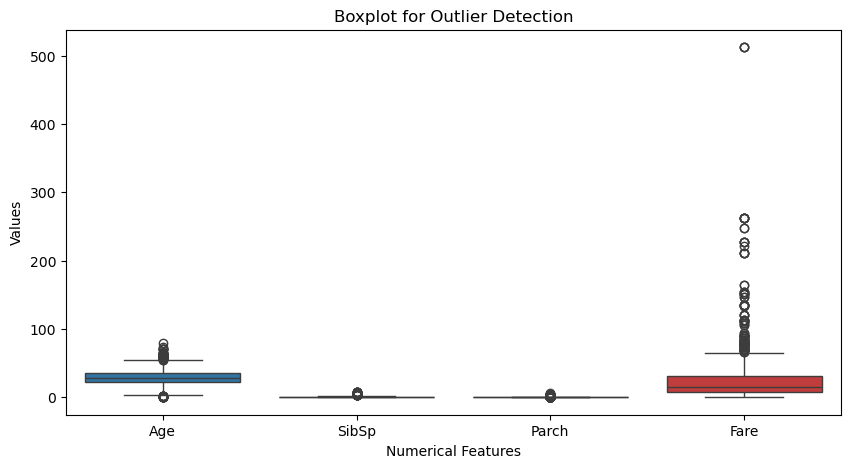

In [26]:
# Visualize Outliers

plt.figure(figsize=(10, 5))

sns.boxplot(data=df_clean[["Age", "SibSp", "Parch", "Fare"]])

plt.title("Boxplot for Outlier Detection")
plt.xlabel("Numerical Features")
plt.ylabel("Values")

plt.show()

## Outlier Detection and Treatment

Outliers were detected using the Interquartile Range (IQR) method.

The numerical variables `Age`, `SibSp`, `Parch`, and `Fare` were examined.

Extreme values were retained rather than removed because they can represent genuine passenger characteristics. For example, higher fare values may correspond to premium tickets, while higher family-related values can represent larger family groups.

Therefore, the detected outliers were considered valid observations and were retained in the cleaned dataset.

In [27]:
# Before vs After Cleaning Summary

summary = pd.DataFrame({
    "Metric": [
        "Number of Rows",
        "Total Missing Values",
        "Duplicate Rows"
    ],
    "Before Cleaning": [
        len(df),
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ],
    "After Cleaning": [
        len(df_clean),
        df_clean.isnull().sum().sum(),
        df_clean.duplicated().sum()
    ]
})

summary

,Metric,Before Cleaning,After Cleaning
0,Number of Rows,891,891
1,Total Missing Values,866,0
2,Duplicate Rows,0,0


In [28]:
# Data Type Comparison

dtype_summary = pd.DataFrame({
    "Column": df.columns,
    "Before Cleaning": df.dtypes.astype(str).values,
    "After Cleaning": df_clean.dtypes.astype(str).values
})

dtype_summary

,Column,Before Cleaning,After Cleaning
0,PassengerId,int64,object
1,Survived,int64,Int64
2,Pclass,int64,Int64
3,Name,object,object
4,Sex,object,object
5,Age,float64,float64
6,SibSp,int64,Int64
7,Parch,int64,Int64
8,Ticket,object,object
9,Fare,float64,float64


In [29]:
# Final Data Quality Check

print("===== FINAL DATA QUALITY CHECK =====")

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

print("\nData types:")
print(df_clean.dtypes)

print("\nFinal dataset shape:")
print(df_clean.shape)

===== FINAL DATA QUALITY CHECK =====

Missing values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Duplicate rows:
0

Data types:
PassengerId     object
Survived         Int64
Pclass           Int64
Name            object
Sex             object
Age            float64
SibSp            Int64
Parch            Int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Final dataset shape:
(891, 12)


## Before vs After Cleaning

The dataset was compared before and after the cleaning process.

The cleaning process included:
- Handling missing values
- Removing duplicate records
- Standardizing text values
- Correcting data types
- Detecting numerical outliers

The final dataset contains consistent formatting, appropriate data types, and no unwanted duplicate records. Detected outliers were retained when they represented valid observations.

In [31]:
# Save Cleaned Dataset

df_clean.to_csv("cleaned_dataset.csv", index=False)

print("Cleaned dataset saved successfully!")
print("File: cleaned_dataset.csv")

Cleaned dataset saved successfully!
File: cleaned_dataset.csv
